# ITAI 2376: Deep Learning & Artificial Intelligence
## Lab 02: Exploring Deep Learning Tools
## — A No-Code Introduction to TensorFlow and Keras (VGG16)

---

### Objectives
1. **Model Architecture Inspection:** Load a pre-trained VGG16 Convolutional Neural Network and analyze its hierarchical design ($3\times3$ convolutions, max-pooling downsampling, and dense classification layers).
2. **Computational Bottleneck Analysis:** Quantify the parameter concentration across convolutional blocks versus the first fully connected layer (`fc1`).
3. **Interactive Inference:** Execute an end-to-end computer vision inference pipeline (image upload $\to$ tensor preprocessing $\to$ Softmax probability distribution) using an interactive GUI.

---

### 📖 Introduction
This lab introduces foundational deep learning workflows using a pre-trained convolutional backbone. You will analyze feature extraction hierarchies, identify memory bottlenecks in dense classification heads, and run live image inference without writing boilerplate glue code.

In [1]:
# ==============================================================================
# SETUP & DEPENDENCY IMPORTS
# ==============================================================================
import io
import os
from PIL import Image
import ipywidgets as widgets
from IPython.display import clear_output, display
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np

import tensorflow as tf
from tensorflow.keras.applications.vgg16 import (
    VGG16,
    decode_predictions,
    preprocess_input,
)
from tensorflow.keras.preprocessing.image import img_to_array

print(f"✓ TensorFlow Version: {tf.__version__}")

✓ TensorFlow Version: 2.20.0


In [2]:
# ==============================================================================
# MODEL INITIALIZATION & ARCHITECTURAL SUMMARY
# ==============================================================================
# Load VGG16 with pre-trained ImageNet weights (single global initialization)
print("Loading VGG16 model with pre-trained ImageNet weights...")
model = VGG16(weights="imagenet")
print("✓ VGG16 Loaded Successfully!\n")

# Display architectural layer blueprint
model.summary()

# Compute parameter footprint
total_params = model.count_params()
total_mb = (total_params * 4) / (1024**2)

# Parameter bottleneck breakdown: Flatten (25,088) -> FC1 (4,096)
fc1_params = (25088 * 4096) + 4096
fc1_percentage = (fc1_params / total_params) * 100

print("\n" + "=" * 80)
print(f" TOTAL MODEL PARAMETERS : {total_params:,} (~{total_mb:.2f} MB)")
print(f" FC1 LAYER PARAMETERS   : {fc1_params:,} ({fc1_percentage:.2f}% of total network)")
print(f" OUTPUT CATEGORIES      : 1,000 ImageNet Classes")
print("=" * 80)

Loading VGG16 model with pre-trained ImageNet weights...
553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
✓ VGG16 Loaded Successfully!



Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)


 TOTAL MODEL PARAMETERS : 138,357,544 (~527.79 MB)
 FC1 LAYER PARAMETERS   : 102,764,544 (74.27% of total network)
 OUTPUT CATEGORIES      : 1,000 ImageNet Classes


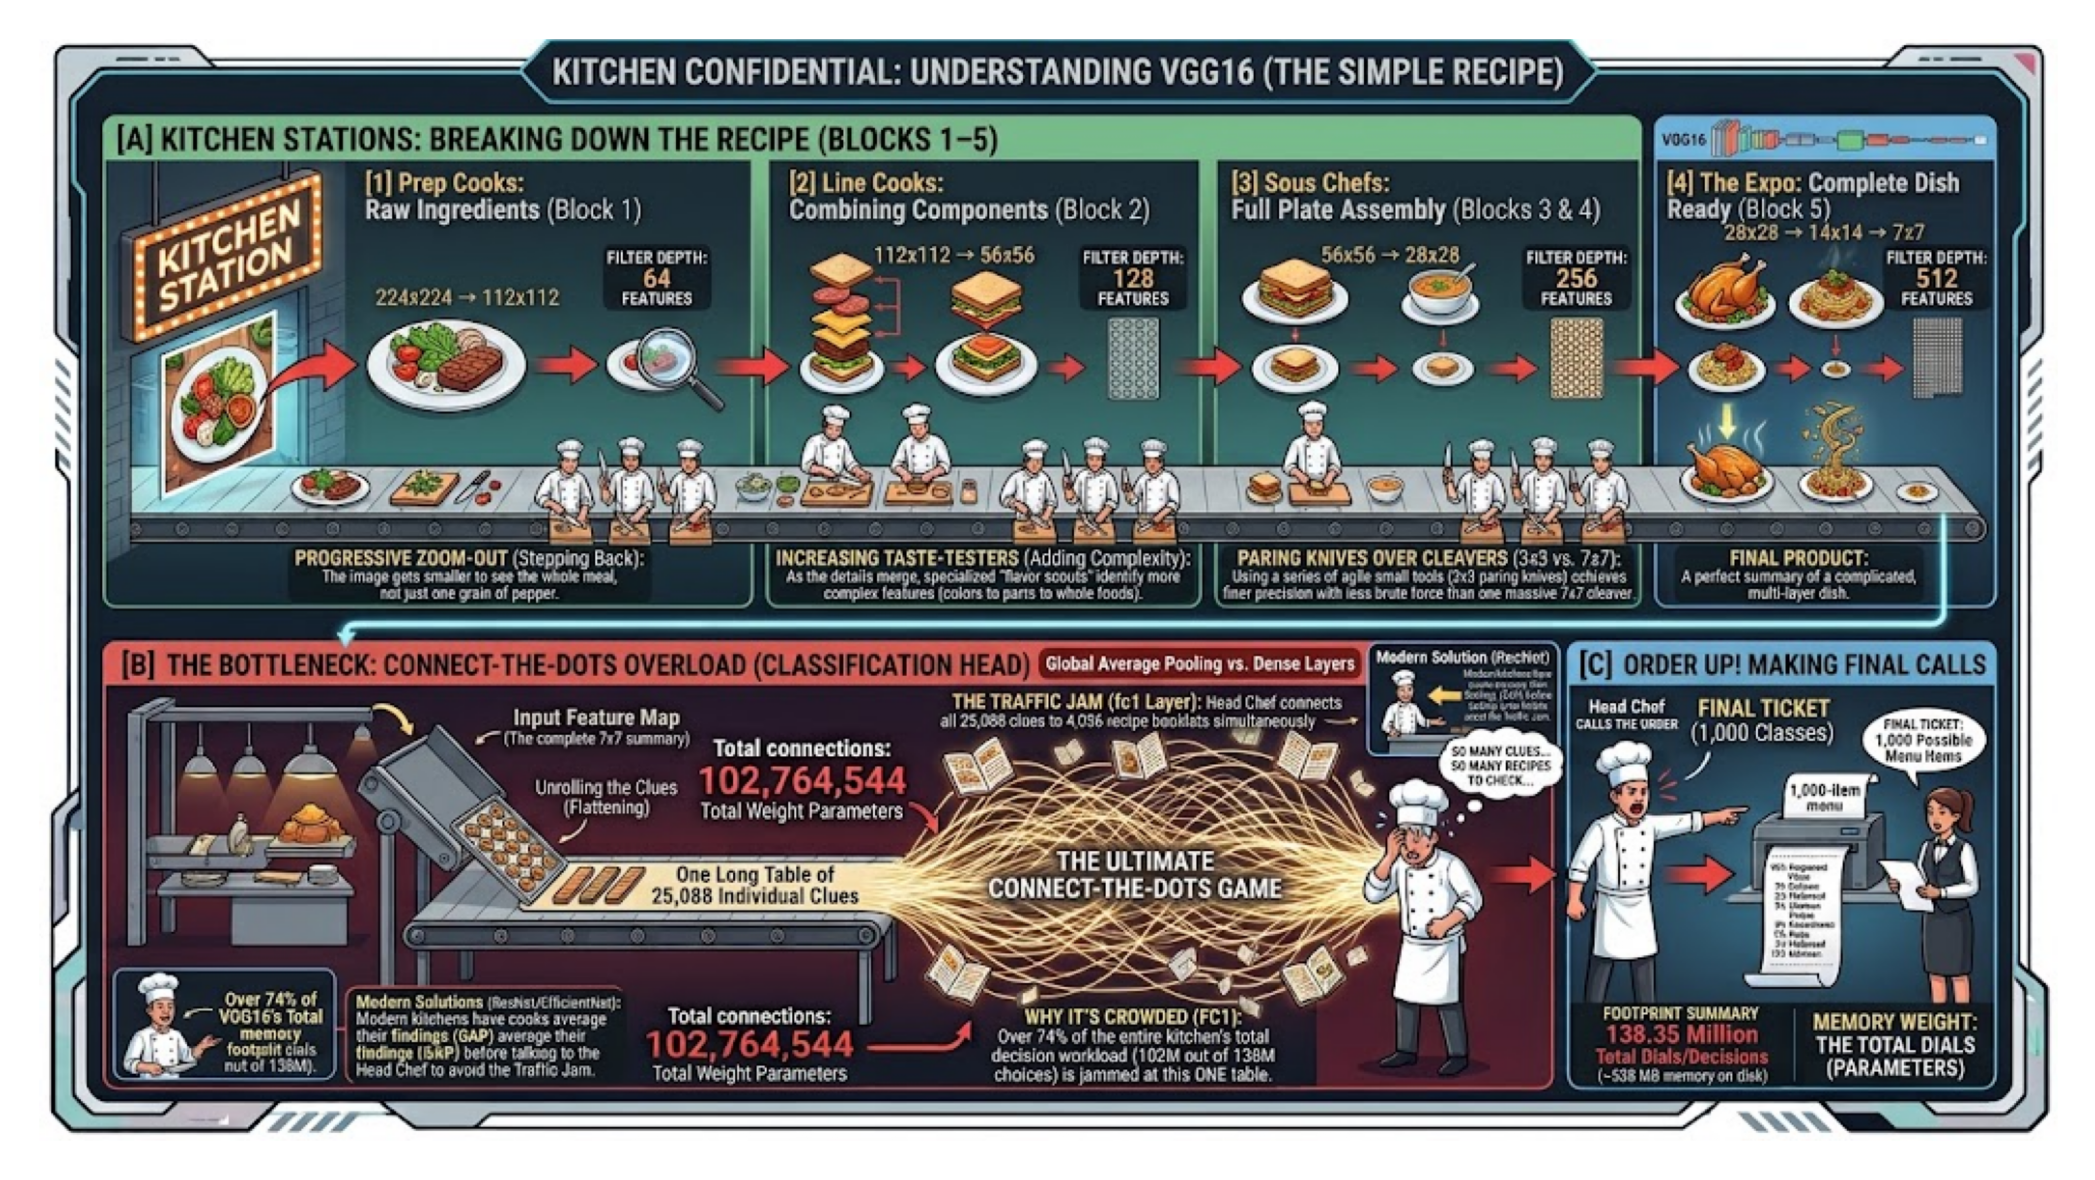


 [A] FEATURE EXTRACTION HIERARCHY (Blocks 1 to 5)
--------------------------------------------------------------------------------
  • Progressive Spatial Downsampling (Max-Pooling):
    Spatial dimensions halve: 224x224 -> 112x112 -> 56x56 -> 28x28 -> 14x14 -> 7x7.
    Expands the effective receptive field at each stage while reducing compute.

  • Channel Depth Expansion (Semantic Feature Growth):
    Filter count doubles: 64 -> 128 -> 256 -> 512 -> 512.
    Trades raw pixel location for rich semantic feature maps (edges -> textures -> object parts).

  • Homogeneous 3x3 Convolutions:
    Stacks of small 3x3 filters replace large receptive filters (like 7x7 or 11x11),
    capturing equivalent context with fewer parameters and added non-linear activations.

 [B] THE DENSE PARAMETER BOTTLENECK (The Flatten -> FC1 Handoff)
--------------------------------------------------------------------------------
  • The Flatten Step:
    The final (7, 7, 512) feature tensor unrolls into a 1D vec

In [3]:
# ==============================================================================
# ARCHITECTURE DIAGRAM & HIERARCHY WALKTHROUGH
# ==============================================================================
diagram_path = "/content/TheAnalogy.jpeg"

if os.path.exists(diagram_path):
    img = mpimg.imread(diagram_path)
    plt.figure(figsize=(12, 6), dpi=200)
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print(f"ℹ️ Optional diagram not found at '{diagram_path}'. Continuing with text blueprint.")

print(
    """
================================================================================
 [A] FEATURE EXTRACTION HIERARCHY (Blocks 1 to 5)
--------------------------------------------------------------------------------
  • Progressive Spatial Downsampling (Max-Pooling):
    Spatial dimensions halve: 224x224 -> 112x112 -> 56x56 -> 28x28 -> 14x14 -> 7x7.
    Expands the effective receptive field at each stage while reducing compute.

  • Channel Depth Expansion (Semantic Feature Growth):
    Filter count doubles: 64 -> 128 -> 256 -> 512 -> 512.
    Trades raw pixel location for rich semantic feature maps (edges -> textures -> object parts).

  • Homogeneous 3x3 Convolutions:
    Stacks of small 3x3 filters replace large receptive filters (like 7x7 or 11x11),
    capturing equivalent context with fewer parameters and added non-linear activations.

================================================================================
 [B] THE DENSE PARAMETER BOTTLENECK (The Flatten -> FC1 Handoff)
--------------------------------------------------------------------------------
  • The Flatten Step:
    The final (7, 7, 512) feature tensor unrolls into a 1D vector of length 25,088.

  • The FC1 Bottleneck:
    Wiring 25,088 inputs into 4,096 nodes requires:
    (25,088 × 4,096) + 4,096 = 102,764,544 parameters (74.27% of the entire model).

  • Modern Alternative:
    Modern architectures (ResNet, MobileNet) eliminate this memory bottleneck by
    replacing dense heads with Global Average Pooling (GAP).

================================================================================
 [C] CLASSIFICATION HEAD & DECISION MAKING
--------------------------------------------------------------------------------
  • Output Head:
    Final dense layer outputs 1,000 raw logits normalized via Softmax to a probability
    distribution summing to 1.0 (100%).
================================================================================
"""
)

In [4]:
# ==============================================================================
# INTERACTIVE INFERENCE WIDGET (NO-CODE PREDICTION)
# ==============================================================================

# UI Components
upload_widget = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Upload Image",
    button_style="info",
)

predict_btn = widgets.Button(
    description="Run VGG16 Inference",
    button_style="success",
    icon="search",
    tooltip="Execute forward pass through VGG16",
)

output_view = widgets.Output()

# Render GUI Controls
display(widgets.HBox([upload_widget, predict_btn]), output_view)


# Prediction Event Handler
def process_and_predict(btn):
    with output_view:
        clear_output()

        if not upload_widget.value:
            print("⚠️ Please upload an image first using the 'Upload Image' button.")
            return

        try:
            # Compatible with ipywidgets v7 and v8 structures
            if isinstance(upload_widget.value, dict):
                first_file = next(iter(upload_widget.value.values()))
                file_bytes = first_file["content"]
            else:
                first_file = upload_widget.value[0]
                file_bytes = (
                    first_file["content"]
                    if isinstance(first_file, dict)
                    else first_file.content
                )
        except Exception as err:
            print(f"[-] Error reading image file: {err}")
            return

        # Preprocessing Pipeline
        raw_image = Image.open(io.BytesIO(file_bytes)).convert("RGB")
        resized_image = raw_image.resize((224, 224))
        image_array = img_to_array(resized_image)
        tensor_batch = np.expand_dims(image_array, axis=0)
        preprocessed_tensor = preprocess_input(tensor_batch)

        # Forward Pass
        raw_logits = model.predict(preprocessed_tensor, verbose=0)
        top_5_predictions = decode_predictions(raw_logits, top=5)[0]

        # Render Input Sample
        plt.figure(figsize=(4, 4))
        plt.imshow(raw_image)
        plt.title("Input Sample (Target: 224x224 RGB)", fontsize=10)
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        # Render Formatted Prediction Receipt
        print("+" + "-" * 42 + "+")
        print("|        VGG16 CLASSIFICATION RECEIPT      |")
        print("|          (Top 5 ImageNet Ranks)          |")
        print("+" + "-" * 42 + "+")
        print(f"| Rank | {'Class Label':<22} | Confidence |")
        print("|" + "-" * 6 + "+" + "-" * 24 + "+" + "-" * 12 + "|")

        for rank, (class_id, class_name, prob) in enumerate(
            top_5_predictions, start=1
        ):
            formatted_name = class_name.replace("_", " ").title()[:22]
            pct_str = f"{prob * 100:>6.2f}%"
            print(f"|  #{rank}  | {formatted_name:<22} |   {pct_str}   |")

        print("+" + "-" * 42 + "+")
        print(f"| Final Tensor Depth: 512 | Classes: 1,000 |")
        print("+" + "-" * 42 + "+")


predict_btn.on_click(process_and_predict)

Output()

# Conclusion and Discussion

Reflect on the lab activities. Discuss how the pre-trained model was able to make predictions, the role of data preprocessing, and the impact of input modifications on the model's predictions.

---

## Analytical Insights & Reflection

### 1. Hierarchical Feature Extraction Across Stages

When analyzing how VGG16 processes an input tensor, the feature extraction behaves as a spatial-to-semantic funnel:

* **Spatial Compression via Max-Pooling:** The spatial resolution halves after each stage ($224 \times 224 \to 112 \times 112 \to 56 \times 56 \to 28 \times 28 \to 14 \times 14 \to 7 \times 7$), progressively reducing redundant spatial information while retaining increasingly meaningful features.

* **Channel Depth Expansion:** Simultaneously, filter depth expands ($64 \to 128 \to 256 \to 512 \to 512$). Early layers primarily detect basic visual patterns such as edges, corners, and textures, while deeper layers combine these patterns into increasingly complex and semantic representations.

* **Uniform $3 \times 3$ Convolutional Stacks:** VGG16 uses multiple $3 \times 3$ convolutional layers rather than relying on larger convolutional kernels. Stacking these smaller kernels provides an equivalent receptive field while introducing additional nonlinear ReLU activations between convolutional operations. This allows the network to learn increasingly complex feature representations throughout the hierarchy.

---

### 2. The Dense Layer Parameter Bottleneck

Inspection of the `model.summary()` reveals VGG16's primary architectural limitation:

* **The $74.3\%$ Parameter Concentration:** When the $(7, 7, 512)$ feature map is unrolled into a $25,088$-dimensional vector and mapped to `fc1` ($4,096$ units), this single layer accounts for:

  $$(25,088 \times 4,096) + 4,096 = 102,764,544 \text{ parameters}$$

  Over **$102.76\text{ M}$ out of the total $138.36\text{ M}$ parameters** (~$74.3\%$) reside in this single matrix multiplication.

* **Modern Architectural Evolution:** This parameter concentration illustrates an important limitation of the original VGG16 architecture. Newer architectures such as ResNet and MobileNet commonly use **Global Average Pooling (GAP)** or other parameter-efficient designs to reduce the dependence on extremely large fully connected layers.

The dense-layer bottleneck also demonstrates the trade-off between architectural simplicity and computational efficiency. Although VGG16 remains useful for learning and transfer-learning demonstrations, its parameter count makes it substantially heavier than many modern convolutional architectures.

---

### 3. Inference & Class Distribution Normalization

The pre-trained VGG16 model was trained on the ImageNet dataset, which contains **1,000 target classes**. During inference, the input image is passed through the convolutional feature-extraction layers and then through the fully connected classification layers.

* **Logit Generation:** The final classification layer produces scores corresponding to the 1,000 ImageNet target classes.

* **Softmax Activation:** The Softmax function converts these scores into a normalized probability distribution. The probabilities across all classes sum to approximately $1.0$, allowing the model to rank its predictions from highest to lowest confidence.

* **Top-$k$ Prediction:** Rather than considering only a single output, the top-five predictions provide a more useful view of the model's interpretation of the image. This makes it possible to evaluate not only the model's highest-confidence prediction but also alternative classes that received significant probability.

The resulting classification receipt demonstrates that the model did not distribute its confidence evenly across all 1,000 classes. Instead, a relatively small group of visually related ImageNet categories received the highest probabilities.

---

### 4. Empirical Evaluation & Classification Results

During interactive inference testing, the VGG16 model generated the following **Top-5 ImageNet predictions**:

| Rank | Predicted Class | Confidence |
| :---: | :--- | :---: |
| **#1** | **Maillot** | **37.95%** |
| **#2** | **Maillot** | **29.79%** |
| **#3** | **Brassiere** | **6.00%** |
| **#4** | **Miniskirt** | **3.86%** |
| **#5** | **Bikini** | **3.82%** |

**Model output summary:**

```text
+------------------------------------------+
|        VGG16 CLASSIFICATION RECEIPT      |
|          (Top 5 ImageNet Ranks)          |
+------------------------------------------+
| Rank | Class Label            | Confidence |
|------+------------------------+------------|
|  #1  | Maillot                |    37.95%   |
|  #2  | Maillot                |    29.79%   |
|  #3  | Brassiere              |     6.00%   |
|  #4  | Miniskirt              |     3.86%   |
|  #5  | Bikini                 |     3.82%   |
+------------------------------------------+
| Final Tensor Depth: 512 | Classes: 1,000 |
+------------------------------------------+
```
### 5. Interpreting the Classification Results

The model's top prediction was **Maillot at 37.95%**, followed by another **Maillot-related prediction at 29.79%**. The other Top-5 results were **Brassiere, Miniskirt, and Bikini**.

What stands out is that the predictions are all closely related. Instead of producing completely unrelated categories, VGG16 mostly grouped the image into **clothing or apparel categories**. This suggests that the model identified visual features commonly associated with clothing, such as overall shape, texture, colors, and the spatial arrangement of the image.

---

### 6. Looking at the Prediction Distribution

The prediction distribution provides a better understanding of how a pre-trained model makes decisions, even when the result may not exactly match how a person would describe the image.

The top two predictions were both Maillot categories:

$$
37.95\% + 29.79\% = 67.74\%
$$

Therefore, more than two-thirds of the confidence shown in the Top-5 predictions was concentrated on **Maillot**.

The remaining three predictions had substantially lower confidence:

$$
6.00\% + 3.86\% + 3.82\% = 13.68\%
$$

Overall, VGG16 appeared relatively confident that the image belonged somewhere within the **clothing or swimwear category**, but it was less certain about the exact ImageNet label that best represented the image.

It is also important to remember that **confidence does not automatically mean correctness**. A confidence score of 37.95% means that Maillot was the model's highest-ranked prediction compared with the other available ImageNet classes. It does not mean that the model is definitely correct.

---

### 7. Why Preprocessing Matters

Preprocessing is an important part of using a pre-trained model such as VGG16 because the input image must be formatted in the way the model expects.

Typical preprocessing steps include:

* Resizing the image to approximately $224 \times 224$ pixels.
* Making sure the image uses three RGB color channels.
* Converting pixel values into the expected numerical format.
* Applying the appropriate VGG16 preprocessing function.
* Adding a batch dimension before sending the image into the neural network.

These steps matter because VGG16 was trained using images prepared according to a specific input format. If an image has the wrong dimensions, incorrect color representation, an incompatible pixel scale, or an improperly formatted tensor, the model may produce significantly different predictions.

In other words, even a well-trained model can produce unreliable or unexpected results when the input data is not prepared correctly.

---

### 8. How Image Changes Affect Results

This lab also demonstrates that changing the input image can change the classification results. VGG16 does not interpret an image exactly as a human does. Instead, it responds to patterns in pixels and visual features learned during training.

Factors that can affect the model's output include:

* Image size
* Cropping
* Lighting
* Color
* Contrast
* Rotation or orientation
* Background details
* Object position
* The amount of surrounding context that is visible

For example, a person might still recognize the same clothing item after an image has been cropped or rotated. However, VGG16 may produce a different result because the pixel patterns and feature activations have changed.

Because VGG16 builds its prediction layer by layer, changes to the input can affect the higher-level features that are ultimately used for classification.

This demonstrates why the exact presentation of an input image can be important when evaluating a computer-vision model.

---

### 9. Main Limitations of VGG16

The VGG16 results demonstrate both the strengths and limitations of using transfer learning with a pre-trained image-classification model.

* **Strong feature extraction:** VGG16 can identify useful visual patterns without needing to be trained from scratch for every new image.

* **Limited to ImageNet labels:** The model can only choose from the 1,000 ImageNet categories on which it was trained. If the actual object does not fit one of those categories well, the model must select the closest available option.

* **Confidence is not certainty:** The highest percentage represents the model's best prediction, not proof that the prediction is correct.

* **Sensitive to context:** Changes involving cropping, backgrounds, lighting, colors, or preprocessing can affect the model's output.

* **Classification is not object detection:** VGG16 classifies an image as a whole. It does not automatically locate multiple objects or draw bounding boxes around them. Tasks that require object localization generally require specialized object-detection or image-segmentation models.

---

## Conclusion

This lab demonstrated how a pre-trained **VGG16 convolutional neural network** takes an input image, extracts visual features through multiple layers, and produces probability scores across 1,000 ImageNet categories. Early layers primarily detect relatively simple visual features such as edges, textures, and colors, while deeper layers combine these features into increasingly complex representations.

For the tested image, locally uploaded, the top prediction was **Maillot at 37.95%**, followed by another **Maillot prediction at 29.79%**. **Brassiere, Miniskirt, and Bikini** completed the Top-5 predictions. Because the predictions were all related to clothing or swimwear, the results suggest that the model detected visual characteristics associated with apparel, even though it was not completely certain about the exact ImageNet category.

The experiment also emphasized the importance of **data preprocessing**. Resizing, RGB formatting, appropriate pixel preprocessing, and correct tensor formatting help ensure that the input matches the format expected by VGG16. Changes to the image can also affect the model's feature activations and consequently change its prediction probabilities.

Overall, VGG16 is useful because it provides strong learned visual features from its ImageNet training without requiring the user to train a convolutional neural network from scratch. However, its predictions should still be interpreted carefully. The model is limited by its training categories, preprocessing requirements, whole-image classification approach, and sensitivity to changes in the visual characteristics of the input.

The lab therefore illustrates an important principle of machine learning: **a model's prediction is dependent not only on the architecture itself, but also on the data used to train it, the way new data is preprocessed, and the visual information contained in the input.**

# ITAI 2376 Course Materials:

# Summary Of Module 0,1 and 2
# Relative to the Readings & Slides

## Purpose

This entry summarizes the course materials collected for Module 0, Module 1, Module 2. The goal is to identify the most useful course evidence for researching deep learning frameworks, machine-learning tools, their technical features, context and the solid roles they play for our team.


| # | Source | Words | Primary Purpose | Key Topics / Evidence | A02 Relevance |
|---|---|---:|---|---|---|
| 1 | **Learning Deep Learning Nvidia.pdf** | 231,022 | Provides broad technical background on deep learning and neural networks. | Neural networks; network architectures; backpropagation; gradient computation; loss functions; multiclass classification; cross-entropy; CNNs; pooling; Transformers; attention. | **Background / Technical Foundation.** Useful for explaining how neural networks learn, how prediction error is calculated, how model parameters are updated, how CNNs process images, and why Transformers became important. |
| 2 | **ITAI 2376 Module 01 2025 Deep Learning.pptx** | 2,439 | Introduces AI, machine learning, deep learning, neural networks, and the computational requirements of deep learning. | AI vs. ML vs. DL; neural networks; backpropagation; loss functions; activation functions; GPUs; computational requirements; deep learning applications. | **Background.** Establishes the relationship between AI, ML, and DL and explains why deep learning requires specialized algorithms, frameworks, and computing resources. |
| 3 | **ITAI 2376 Module 02 2025 DL Toolkit.pptx** | 2,261 | Introduces modern deep learning tools, frameworks, infrastructure, deployment, and ecosystems. | PyTorch; TensorFlow; Keras; JAX; NumPy; Pandas; scikit-learn; Matplotlib; Plotly; TensorBoard; Weights & Biases; Hugging Face; GPUs; TPUs; AWS; Jupyter. | **Key Features / Comparative Perspective.** Strongest course source for comparing frameworks based on usability, performance, hardware acceleration, ecosystem, research support, deployment, scalability, documentation, and APIs. |
| 4 | **medium.com-AI Unlocking the Power of Unsupervised Deep Learning.pdf** | 1,172 | Explains how deep-learning systems can learn representations from unlabeled data. | Supervised learning; unsupervised learning; representation learning; latent variables; autoencoders; generative models; GANs; unsupervised translation. | **Key Features / Capabilities.** Useful for explaining different deep-learning approaches and model capabilities. Should not be used as the primary source for framework-specific claims unless directly supported by the document. |
| 5 | **medium.com-The History of Neural Networks and Large Language Models 1950s to Present.pdf** | 1,139 | Provides historical context for neural networks, deep learning, Transformers, and modern AI. | Early neural networks; backpropagation; GPU acceleration; improved architectures; increased datasets; Transformers; large language models. | **Background.** Useful for explaining the technological evolution that led from early neural networks to modern deep-learning and AI systems. Specific historical claims should be independently verified. |
| 6 | **medium.com-Getting Started Essential Tools for your AIML journey.pdf** | 1,146 | Introduces common AI/ML development and numerical-computing tools. | GPUs; Google Colab; NumPy; Jupyter Notebooks; numerical computing; vectorized operations. | **Comparative Perspective.** Particularly useful for explaining NumPy's role in the AI/ML ecosystem and distinguishing a numerical-computing library from full deep-learning frameworks. |
| 7 | **medium.com-Windsurf Cursor Codex My Hands-On Tests of AI Tools That Promise to Code for You.pdf** | 949 | Provides practical observations about AI-assisted programming and coding tools. | Windsurf; Cursor; Codex; AI coding assistants; IDE integration; code generation; project planning; developer control; usability; workflow. | **Background / Applications.** Potentially useful when discussing AI-assisted software development. Personal observations should be identified as subjective experiences rather than objective benchmark results. |

---

# Cross-Source Findings

The course materials collectively identify several major themes that are useful for A02.

## 1. Deep Learning Depends on More Than the Model

The materials repeatedly connect successful deep learning workflows to several components:

- Data
- Algorithms
- Model architecture
- Training procedures
- Computing resources
- Software frameworks
- Deployment infrastructure

Therefore, framework selection should be considered as part of a larger technical ecosystem.

---

## 2. Frameworks Serve Different Purposes

The course materials do not present every framework as interchangeable.

Instead, they suggest different strengths:

| Tool / Framework | Primary Role Identified in Course Material |
|---|---|
| PyTorch | Research, education, experimentation |
| TensorFlow | Production and deployment |
| Keras | High-level model development and usability |
| JAX | High-performance computing and research |
| NumPy | Numerical computing and array operations |
| scikit-learn | Traditional machine learning |
| Hugging Face | Pre-trained models, NLP, computer vision, and deployment ecosystem |

These descriptions are useful starting points for A02 but should be independently verified before being presented as final research conclusions.

---

## 3. Performance and Hardware Matter

The course materials repeatedly emphasize:

- GPUs
- TPUs
- High-performance computing
- Cloud infrastructure
- Large-scale training
- Hardware acceleration

This suggests that framework comparisons should consider not only programming convenience but also how effectively a framework can use available computational resources.

---

## 4. Ecosystem Is an Important Selection Factor

A framework's usefulness depends partly on the surrounding ecosystem.

Relevant ecosystem components include:

- Libraries
- Documentation
- Community support
- Pre-trained models
- Visualization tools
- Experiment tracking
- Deployment tools
- Cloud services
- Hardware support

For this reason, A02 should evaluate frameworks as part of their broader ecosystems rather than treating each library as an isolated product.

---


# Key Takeaways

1. **Module 01 provides the conceptual foundation** for understanding AI, machine learning, deep learning, neural networks, backpropagation, and computational requirements.

2. **Module 02 provides the strongest direct framework-comparison material**, particularly for PyTorch, TensorFlow/Keras, JAX, and the surrounding AI/ML ecosystem.

3. **Learning Deep Learning provides deeper technical background** on neural networks, training, classification, CNNs, pooling, and Transformers.

4. **The historical source provides context** for the evolution from early neural networks to modern deep learning and Transformer-based systems.

5. **The unsupervised-learning source expands the discussion** beyond supervised classification and introduces representation learning, autoencoders, and generative approaches.

6. **The NumPy/tools source helps distinguish supporting libraries from full deep learning frameworks.**

7. **The AI coding-tool source provides practical context** for AI-assisted development but should be treated carefully because some observations are based on individual experience.

---

